# Exploratory Data Analysis — Chest X-Ray Pneumonia Dataset

This section performs a full EDA **before any model training**. It is read-only: no files are
moved, modified, or deleted. It is meant to be inserted into the existing project notebook
(after the dataset has been downloaded / `BASE_DIR` defined), or run standalone on Kaggle.

**Contents**

1. Dataset Overview
2. Class Imbalance Analysis
3. Sample Visualization
4. Image Properties
5. Pixel Statistics
6. Image Quality Assessment
7. Duplicate & Data Leakage Detection
8. Feature-Space Visualization (Deep Features)
9. Statistical Summary
10. Recommendations


## 0. Setup & Imports

In [7]:
# Core libraries
import os
import json
import hashlib
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from PIL import Image, ImageFile
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
# Allow PIL to attempt loading truncated files instead of crashing —
# we want to *flag* them as corrupted, not have the notebook die on them.
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ------------------------------------------------------------------
# Optional dependencies not always preinstalled on Kaggle/Colab
# ------------------------------------------------------------------
try:
    import imagehash
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'imagehash'])
    import imagehash

try:
    import umap
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'umap-learn'])
    import umap

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# ------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------
# Publication-quality plot defaults
# ------------------------------------------------------------------
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.facecolor': 'white',
    'savefig.bbox': 'tight',
})

CLASS_NAMES = ['NORMAL', 'PNEUMONIA']
PALETTE = {'NORMAL': '#3B82C4', 'PNEUMONIA': '#D9534F'}

EDA_DIR = 'eda_outputs'
os.makedirs(f'{EDA_DIR}/figures', exist_ok=True)

# GPU check — Kaggle: Settings -> Accelerator -> GPU T4/P100. Feature extraction in
# Section 8 (MobileNetV2) will automatically use the GPU if TensorFlow detects one;
# nothing else in this EDA needs a GPU (it's all NumPy/OpenCV/PIL on CPU).
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs detected: {len(gpus)}', gpus if gpus else '(running on CPU — Section 8 will be slower but still correct)')

print('Environment ready.')


GPUs detected: 2 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Environment ready.


### Dataset path resolution

If this cell is appended to the existing project notebook, `BASE_DIR` is already defined
(`chest_xray_data/chest_xray`). If this EDA is run standalone (e.g. directly on Kaggle), it
searches `/kaggle/input` for a folder structure matching `train/val/test` with `NORMAL`/
`PNEUMONIA` subfolders (works regardless of which exact dataset slug Kaggle mounted it under).
Edit `_candidate_paths` / the search root if your setup differs.

In [8]:
def _is_valid_base_dir(path):
    """A valid BASE_DIR must be a real directory containing at least one of
    train/val/test, each themselves containing NORMAL/PNEUMONIA subfolders."""
    if not isinstance(path, str) or not path or not os.path.isdir(path):
        return False
    for split in ('train', 'val', 'test', 'train_new', 'val_new'):
        split_path = os.path.join(path, split)
        if os.path.isdir(split_path):
            subfolders = {d.upper() for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))}
            if subfolders & {'NORMAL', 'PNEUMONIA'}:
                return True
    return False

def _search_kaggle_input(root='/kaggle/input', max_depth=4):
    """Walk /kaggle/input looking for a chest_xray-style folder, in case the exact
    mount path/slug differs from the dataset's usual name."""
    if not os.path.isdir(root):
        return None
    root_depth = root.rstrip('/').count('/')
    for dirpath, dirnames, _ in os.walk(root):
        if dirpath.rstrip('/').count('/') - root_depth > max_depth:
            dirnames[:] = []
            continue
        if _is_valid_base_dir(dirpath):
            return dirpath
    return None

# Only reuse a pre-existing BASE_DIR from the surrounding notebook if it is actually
# a valid, existing string path (avoids crashing on a stale/None BASE_DIR left over
# from a previous, unrelated cell in the same kernel session).
_existing_base_dir = globals().get('BASE_DIR', None)

_candidate_paths = []
if _is_valid_base_dir(_existing_base_dir):
    _candidate_paths.append(_existing_base_dir)

_candidate_paths += [
    '/kaggle/input/chest-xray-pneumonia/chest_xray',
    '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray',
    'chest_xray_data/chest_xray',
    'chest_xray',
]

BASE_DIR = next((p for p in _candidate_paths if _is_valid_base_dir(p)), None)

if BASE_DIR is None:
    print('No candidate path matched — searching /kaggle/input recursively...')
    BASE_DIR = _search_kaggle_input()

if BASE_DIR is None:
    raise FileNotFoundError(
        'Could not locate the chest_xray dataset automatically. On Kaggle, add the '
        '"Chest X-Ray Images (Pneumonia)" dataset via Add Data, then set BASE_DIR manually, e.g.\n'
        '    BASE_DIR = "/kaggle/input/chest-xray-pneumonia/chest_xray"\n'
        f'Tried: {_candidate_paths}'
    )

print(f'Using dataset root: {BASE_DIR}')

# Prefer the rebalanced 80/20 splits (train_new / val_new) if that cell has already
# been run earlier in the notebook; otherwise fall back to the folders shipped with
# the raw dataset (train / val / test).
SPLIT_DIRS = {
    'train': 'train_new' if os.path.isdir(f'{BASE_DIR}/train_new') else 'train',
    'val':   'val_new'   if os.path.isdir(f'{BASE_DIR}/val_new')   else 'val',
    'test':  'test',
}

for split, folder in SPLIT_DIRS.items():
    full_path = f'{BASE_DIR}/{folder}'
    print(f'  {split:5s} -> {full_path}  (exists: {os.path.isdir(full_path)})')


No candidate path matched — searching /kaggle/input recursively...
Using dataset root: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
  train -> /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train  (exists: True)
  val   -> /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val  (exists: True)
  test  -> /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test  (exists: True)


## 1. Dataset Overview

In [9]:
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

def build_manifest(base_dir, split_dirs):
    """Walk every split/class folder and build one row per image file."""
    records = []
    for split, folder in split_dirs.items():
        split_path = os.path.join(base_dir, folder)
        if not os.path.isdir(split_path):
            continue
        class_dirs = sorted(
            d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))
        )
        for class_name in class_dirs:
            class_path = os.path.join(split_path, class_name)
            for fname in os.listdir(class_path):
                if fname.lower().endswith(IMG_EXTENSIONS):
                    fpath = os.path.join(class_path, fname)
                    records.append({
                        'filepath': fpath,
                        'filename': fname,
                        'split': split,
                        'class': class_name.upper(),
                        'filesize_kb': os.path.getsize(fpath) / 1024.0,
                    })
    return pd.DataFrame(records)

manifest_df = build_manifest(BASE_DIR, SPLIT_DIRS)

print(f'Total images found : {len(manifest_df):,}')
print(f'Classes             : {sorted(manifest_df["class"].unique().tolist())}')
print(f'Splits              : {sorted(manifest_df["split"].unique().tolist())}')

manifest_df.head()


Total images found : 5,856
Classes             : ['NORMAL', 'PNEUMONIA']
Splits              : ['test', 'train', 'val']


,filepath,filename,split,class,filesize_kb
0,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL2-IM-0771-0001.jpeg,train,NORMAL,148.803711
1,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL2-IM-1294-0001-0002.jpeg,train,NORMAL,527.088867
2,/kaggle/input/datasets/paultimothymooney/chest...,IM-0675-0001.jpeg,train,NORMAL,341.994141
3,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL2-IM-1169-0001.jpeg,train,NORMAL,614.438477
4,/kaggle/input/datasets/paultimothymooney/chest...,IM-0421-0001.jpeg,train,NORMAL,451.316406


In [10]:
overview_table = manifest_df.groupby(['split', 'class']).size().unstack(fill_value=0)
overview_table['Total'] = overview_table.sum(axis=1)
overview_table.loc['Total'] = overview_table.sum(axis=0)

display(overview_table)
overview_table.to_csv(f'{EDA_DIR}/dataset_overview.csv')


class,NORMAL,PNEUMONIA,Total
split,,,
test,234,390,624
train,1341,3875,5216
val,8,8,16
Total,1583,4273,5856


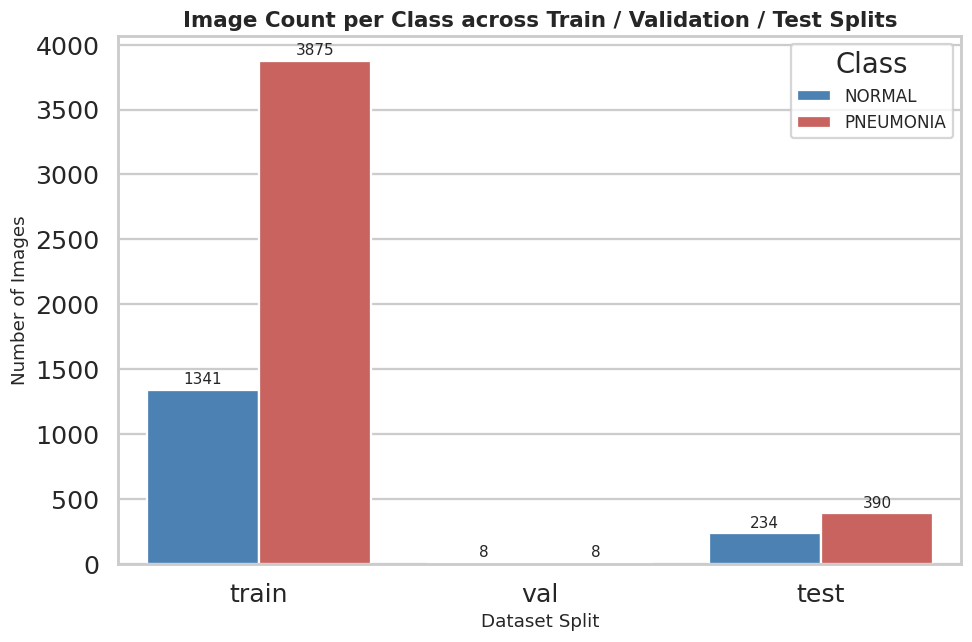

In [11]:
plot_df = manifest_df.groupby(['split', 'class']).size().reset_index(name='count')
split_order = [s for s in ['train', 'val', 'test'] if s in plot_df['split'].unique()]

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=plot_df, x='split', y='count', hue='class',
    order=split_order, hue_order=CLASS_NAMES, palette=PALETTE, ax=ax
)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2, fontsize=10)

ax.set_title('Image Count per Class across Train / Validation / Test Splits')
ax.set_xlabel('Dataset Split')
ax.set_ylabel('Number of Images')
ax.legend(title='Class')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/figures/01_split_class_counts.png')
plt.show()


## 2. Class Imbalance Analysis

In [12]:
class_counts = manifest_df['class'].value_counts().reindex(CLASS_NAMES)
class_pct = (class_counts / class_counts.sum() * 100).round(2)

imbalance_df = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pct})
display(imbalance_df)

imbalance_ratio = class_counts.max() / class_counts.min()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

print(f'Imbalance ratio ({majority_class} : {minority_class}) = {imbalance_ratio:.2f} : 1')


,Count,Percentage (%)
class,,
NORMAL,1583,27.03
PNEUMONIA,4273,72.97


Imbalance ratio (PNEUMONIA : NORMAL) = 2.70 : 1


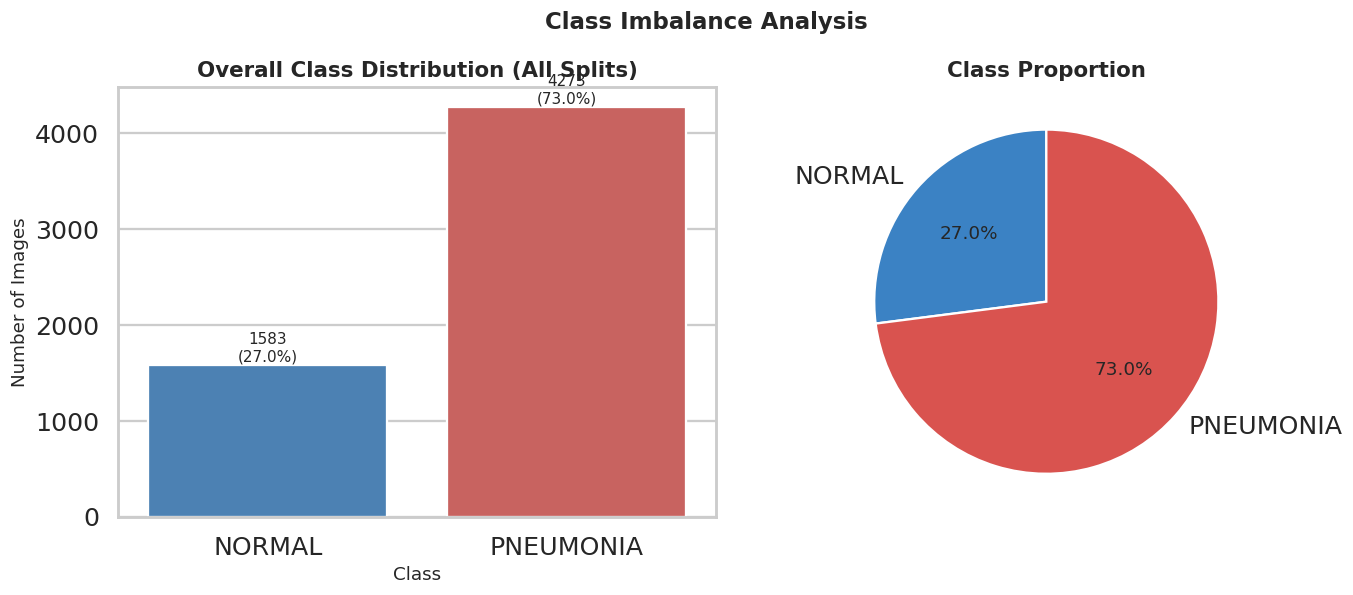

Discussion: the dataset is imbalanced (ratio 2.70:1). Consider class weighting (already used later in this notebook via compute_class_weight), minority-class oversampling, or a focal loss to keep the model from being biased toward PNEUMONIA.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sns.barplot(x=class_counts.index, y=class_counts.values,
            palette=[PALETTE[c] for c in class_counts.index], ax=axes[0])
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + class_counts.values.max() * 0.01, f'{v}\n({class_pct.iloc[i]:.1f}%)',
                 ha='center', fontsize=10)
axes[0].set_title('Overall Class Distribution (All Splits)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')

axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=[PALETTE[c] for c in class_counts.index], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Proportion')

plt.suptitle('Class Imbalance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/figures/02_class_imbalance.png')
plt.show()

is_imbalanced = imbalance_ratio > 1.5
print(
    f"Discussion: the dataset is {'imbalanced' if is_imbalanced else 'roughly balanced'} "
    f"(ratio {imbalance_ratio:.2f}:1).",
    ("Consider class weighting (already used later in this notebook via compute_class_weight), "
     "minority-class oversampling, or a focal loss to keep the model from being biased toward "
     f"{majority_class}.") if is_imbalanced else ""
)


## 3. Sample Visualization

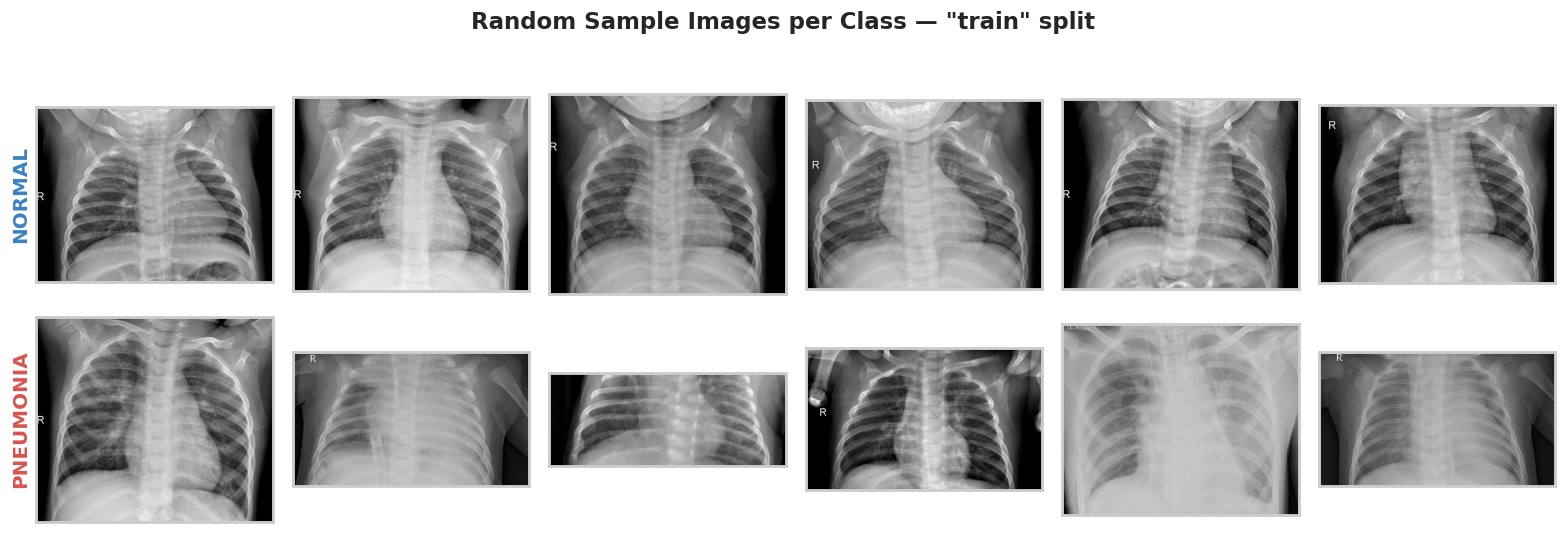

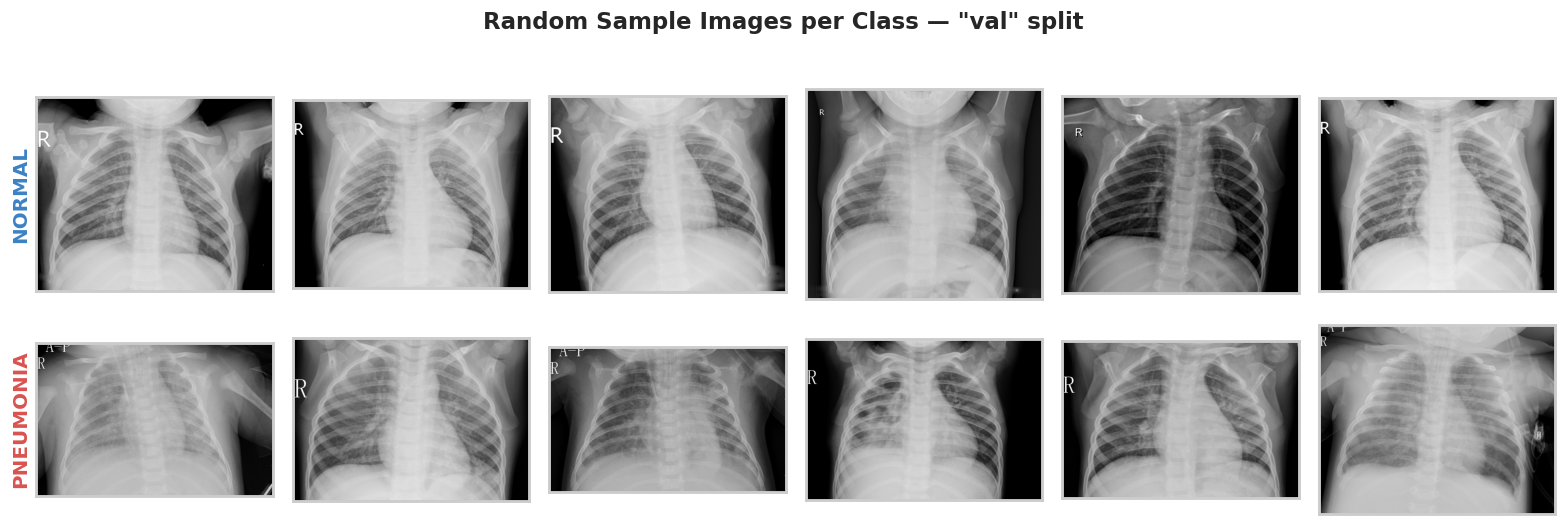

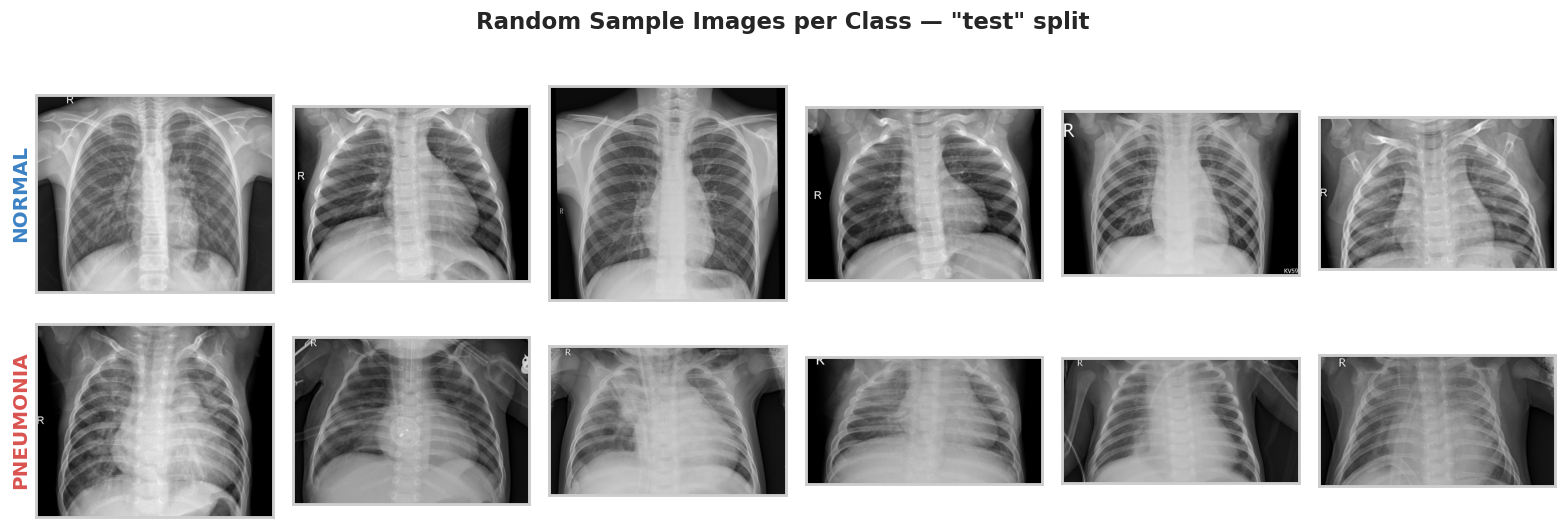

In [14]:
def show_class_samples(df, split='train', n_per_class=6, seed=SEED):
    rng = np.random.default_rng(seed)
    split_df = df[df['split'] == split]
    classes = sorted(split_df['class'].unique())

    fig, axes = plt.subplots(len(classes), n_per_class,
                              figsize=(2.4 * n_per_class, 2.6 * len(classes)))
    if len(classes) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, cls in enumerate(classes):
        cls_paths = split_df.loc[split_df['class'] == cls, 'filepath'].values
        chosen = rng.choice(cls_paths, size=min(n_per_class, len(cls_paths)), replace=False)
        for col in range(n_per_class):
            ax = axes[row, col]
            if col < len(chosen):
                img = Image.open(chosen[col]).convert('L')
                ax.imshow(img, cmap='gray')
                if col == 0:
                    ax.set_ylabel(cls, fontsize=13, fontweight='bold',
                                  color=PALETTE.get(cls, 'black'))
            ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle(f'Random Sample Images per Class — "{split}" split', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{EDA_DIR}/figures/03_samples_{split}.png')
    plt.show()

for _split in split_order:
    show_class_samples(manifest_df, split=_split, n_per_class=6)


## 4. Image Properties

In [15]:
# Sampling keeps this section fast on Kaggle while remaining statistically representative.
# Increase PROPS_SAMPLE_N for a more exhaustive (slower) pass.
PROPS_SAMPLE_N = 400  # images per class, drawn proportionally across splits

def stratified_sample(df, n_per_class, seed=SEED):
    return (
        df.groupby('class', group_keys=False)
          .apply(lambda g: g.sample(min(len(g), n_per_class), random_state=seed))
          .reset_index(drop=True)
    )

props_sample_df = stratified_sample(manifest_df, PROPS_SAMPLE_N)

def get_image_properties(filepath):
    try:
        with Image.open(filepath) as img:
            return img.size[0], img.size[1], img.mode
    except Exception:
        return None, None, None

props_records = []
for _, row in tqdm(props_sample_df.iterrows(), total=len(props_sample_df),
                    desc='Reading image properties'):
    w, h, mode = get_image_properties(row['filepath'])
    props_records.append({**row.to_dict(), 'width': w, 'height': h, 'mode': mode})

props_df = pd.DataFrame(props_records).dropna(subset=['width', 'height'])
props_df['aspect_ratio'] = props_df['width'] / props_df['height']

props_df[['width', 'height', 'aspect_ratio']].describe().round(2).T


Reading image properties:   0%|          | 0/800 [00:00<?, ?it/s]

,count,mean,std,min,25%,50%,75%,max
width,800.0,1449.80,376.56,384.00,1168.00,1438.00,1680.50,2890.00
height,800.0,1102.87,410.46,127.00,782.00,1056.00,1356.00,2628.00
aspect_ratio,800.0,1.39,0.26,0.88,1.21,1.35,1.52,3.38


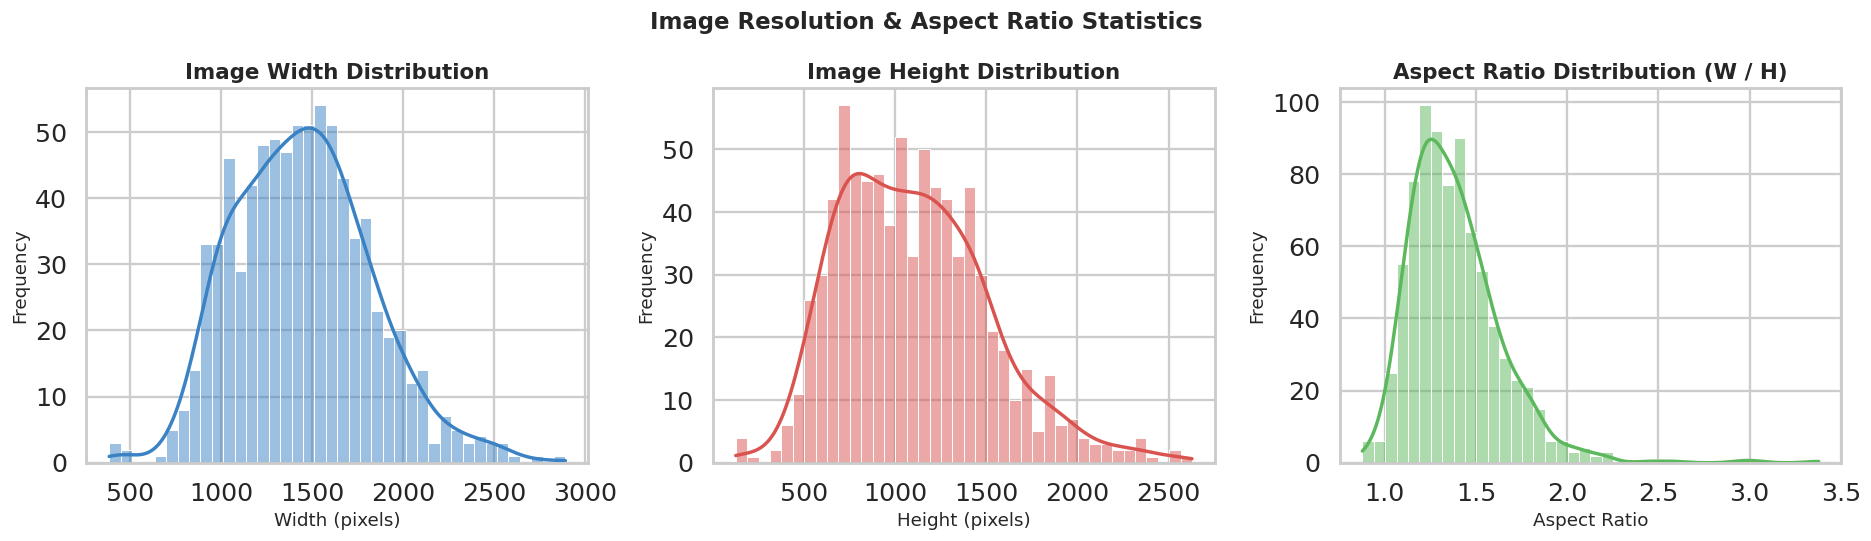

,width,height,aspect_ratio
mean,1449.80,1102.87,1.39
median,1438.00,1056.00,1.35
std,376.56,410.46,0.26
min,384.00,127.00,0.88
max,2890.00,2628.00,3.38


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.histplot(props_df['width'], bins=40, kde=True, ax=axes[0], color='#3B82C4')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (pixels)'); axes[0].set_ylabel('Frequency')

sns.histplot(props_df['height'], bins=40, kde=True, ax=axes[1], color='#D9534F')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (pixels)'); axes[1].set_ylabel('Frequency')

sns.histplot(props_df['aspect_ratio'], bins=40, kde=True, ax=axes[2], color='#5CB85C')
axes[2].set_title('Aspect Ratio Distribution (W / H)')
axes[2].set_xlabel('Aspect Ratio'); axes[2].set_ylabel('Frequency')

plt.suptitle('Image Resolution & Aspect Ratio Statistics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/figures/04_image_properties.png')
plt.show()

resolution_stats = props_df[['width', 'height', 'aspect_ratio']].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2)
display(resolution_stats)


## 5. Pixel Statistics

In [17]:
def compute_pixel_stats(filepath, size=(224, 224)):
    img = cv2.imread(filepath, cv2.IMREAD_COLOR)
    if img is None:
        return None
    img = cv2.resize(img, size)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    mean_rgb = img_rgb.reshape(-1, 3).mean(axis=0)
    std_rgb = img_rgb.reshape(-1, 3).std(axis=0)
    brightness = float(img_rgb.mean())
    return mean_rgb, std_rgb, brightness

pixel_records = []
for _, row in tqdm(props_sample_df.iterrows(), total=len(props_sample_df),
                    desc='Computing pixel statistics'):
    result = compute_pixel_stats(row['filepath'])
    if result is None:
        continue
    mean_rgb, std_rgb, brightness = result
    pixel_records.append({
        'class': row['class'], 'split': row['split'],
        'mean_R': mean_rgb[0], 'mean_G': mean_rgb[1], 'mean_B': mean_rgb[2],
        'std_R': std_rgb[0], 'std_G': std_rgb[1], 'std_B': std_rgb[2],
        'brightness': brightness,
    })

pixel_df = pd.DataFrame(pixel_records)
pixel_df[['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B', 'brightness']].describe().round(4).T


Computing pixel statistics:   0%|          | 0/800 [00:00<?, ?it/s]

,count,mean,std,min,25%,50%,75%,max
mean_R,800.0,0.4798,0.0673,0.2592,0.4404,0.4797,0.5213,0.7219
mean_G,800.0,0.4798,0.0673,0.2592,0.4404,0.4797,0.5213,0.7219
mean_B,800.0,0.4798,0.0673,0.2592,0.4404,0.4797,0.5213,0.7219
std_R,800.0,0.2290,0.0340,0.1157,0.2079,0.2310,0.2537,0.3224
std_G,800.0,0.2290,0.0340,0.1157,0.2079,0.2310,0.2537,0.3224
std_B,800.0,0.2290,0.0340,0.1157,0.2079,0.2310,0.2537,0.3224
brightness,800.0,0.4798,0.0672,0.2592,0.4405,0.4797,0.5213,0.7218


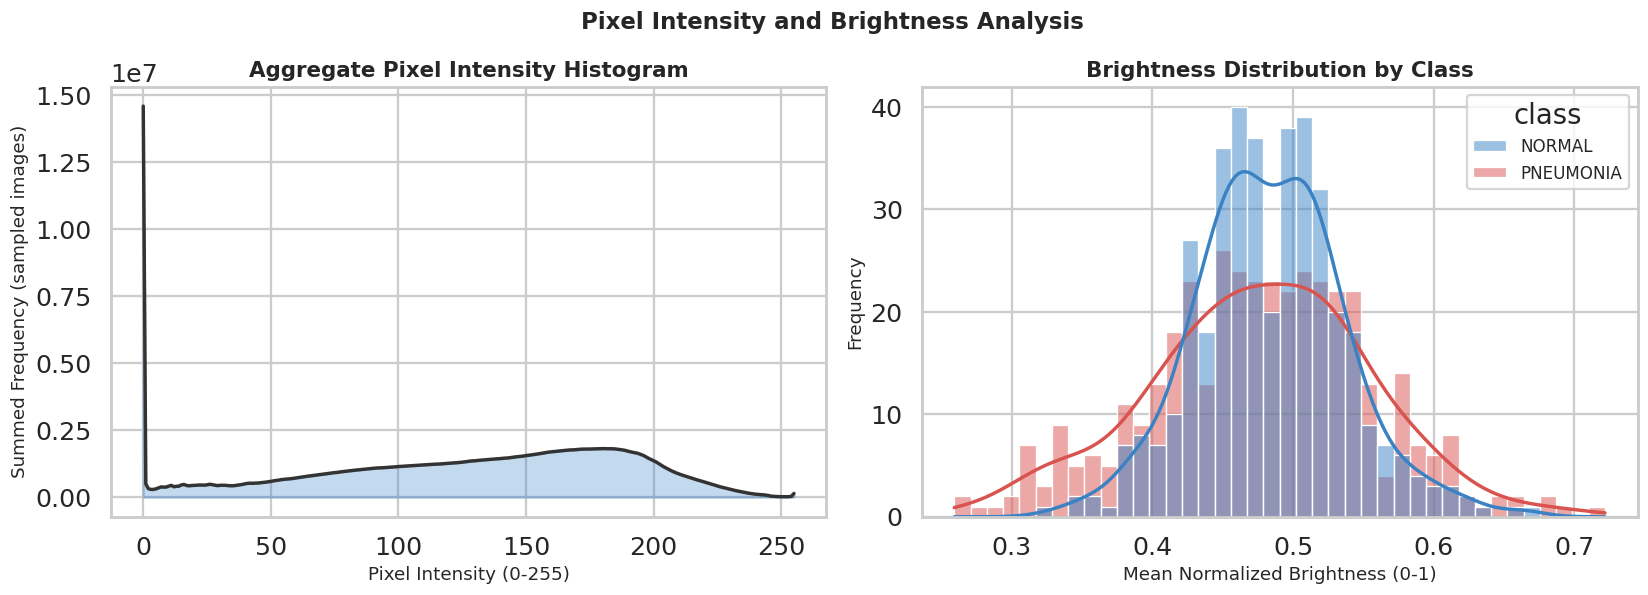

In [18]:
def aggregate_intensity_histogram(df, n_images=150, bins=256, seed=SEED):
    rng = np.random.default_rng(seed)
    paths = rng.choice(df['filepath'].values, size=min(n_images, len(df)), replace=False)
    hist_total = np.zeros(bins)
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        h, _ = np.histogram(img, bins=bins, range=(0, 255))
        hist_total += h
    return hist_total

hist_total = aggregate_intensity_histogram(props_sample_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].plot(hist_total, color='#333333')
axes[0].fill_between(range(len(hist_total)), hist_total, alpha=0.3, color='#3B82C4')
axes[0].set_title('Aggregate Pixel Intensity Histogram')
axes[0].set_xlabel('Pixel Intensity (0-255)')
axes[0].set_ylabel('Summed Frequency (sampled images)')

sns.histplot(data=pixel_df, x='brightness', hue='class', bins=40, kde=True,
             palette=PALETTE, ax=axes[1])
axes[1].set_title('Brightness Distribution by Class')
axes[1].set_xlabel('Mean Normalized Brightness (0-1)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Pixel Intensity and Brightness Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/figures/05_pixel_statistics.png')
plt.show()


## 6. Image Quality Assessment

In [19]:
def assess_image_quality(filepath):
    try:
        img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return {'corrupted': True, 'blur_score': np.nan, 'brightness': np.nan, 'contrast': np.nan}
        blur_score = cv2.Laplacian(img, cv2.CV_64F).var()
        return {'corrupted': False, 'blur_score': blur_score,
                'brightness': float(img.mean()), 'contrast': float(img.std())}
    except Exception:
        return {'corrupted': True, 'blur_score': np.nan, 'brightness': np.nan, 'contrast': np.nan}

def verify_image_integrity(filepath):
    try:
        with Image.open(filepath) as img:
            img.verify()
        return True
    except Exception:
        return False

quality_records = []
for _, row in tqdm(props_sample_df.iterrows(), total=len(props_sample_df),
                    desc='Assessing image quality'):
    metrics = assess_image_quality(row['filepath'])
    metrics['pil_valid'] = verify_image_integrity(row['filepath'])
    quality_records.append({**row.to_dict(), **metrics})

quality_df = pd.DataFrame(quality_records)
quality_df['corrupted'] = quality_df['corrupted'] | (~quality_df['pil_valid'])

n_corrupted = int(quality_df['corrupted'].sum())
print(f'Corrupted / unreadable images detected in sample: {n_corrupted} / {len(quality_df)} '
      f'({n_corrupted / len(quality_df) * 100:.2f}%)')

# Laplacian-variance rule of thumb: below this, an image is flagged as likely blurry.
# This threshold is dataset-dependent — inspect the flagged images before discarding any.
BLUR_THRESHOLD = 100

blurry_df = quality_df[(quality_df['blur_score'] < BLUR_THRESHOLD) & (~quality_df['corrupted'])]
print(f'Likely blurry images (Laplacian variance < {BLUR_THRESHOLD}): '
      f'{len(blurry_df)} ({len(blurry_df) / len(quality_df) * 100:.2f}%)')


Assessing image quality:   0%|          | 0/800 [00:00<?, ?it/s]

Corrupted / unreadable images detected in sample: 0 / 800 (0.00%)
Likely blurry images (Laplacian variance < 100): 244 (30.50%)


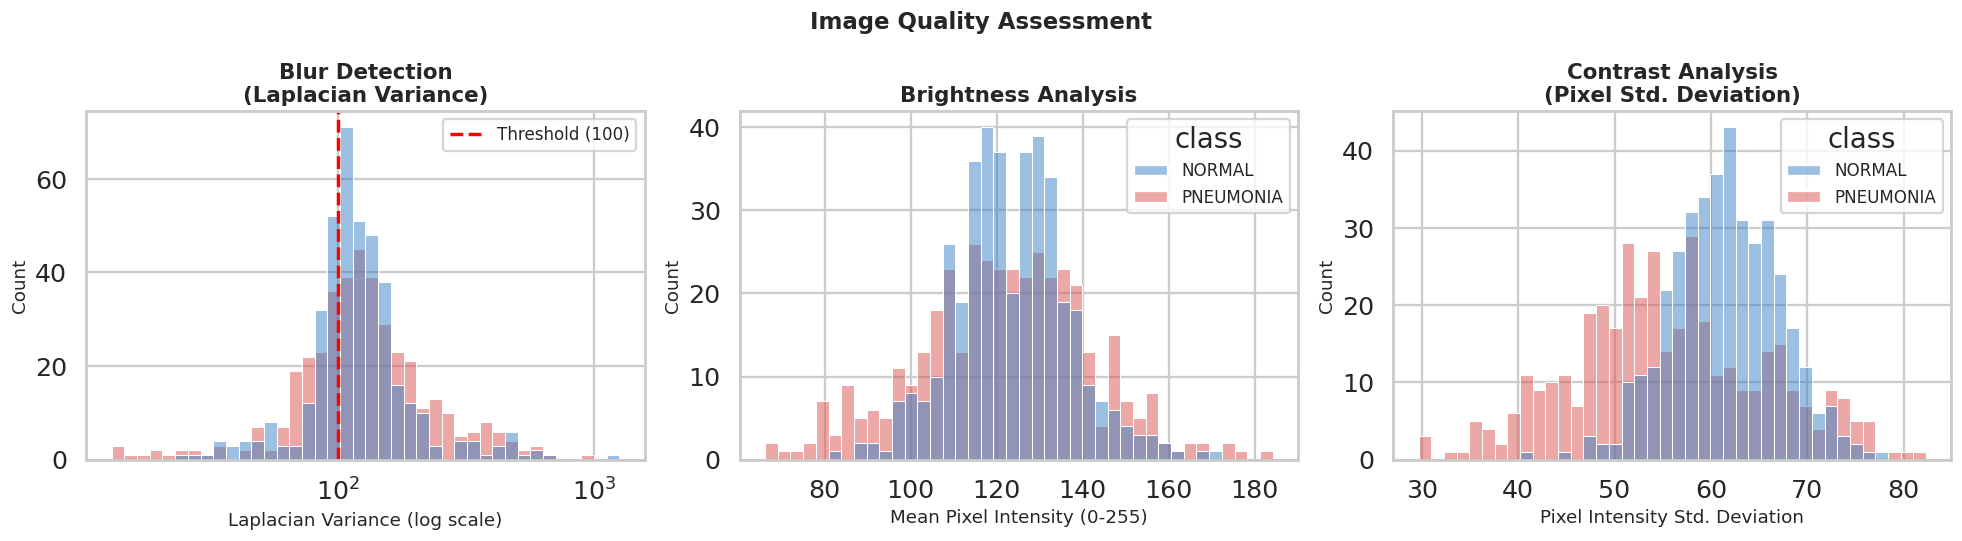

In [20]:
valid_quality_df = quality_df[~quality_df['corrupted']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=valid_quality_df, x='blur_score', hue='class', bins=40,
             palette=PALETTE, ax=axes[0], log_scale=(True, False))
axes[0].axvline(BLUR_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({BLUR_THRESHOLD})')
axes[0].set_title('Blur Detection\n(Laplacian Variance)')
axes[0].set_xlabel('Laplacian Variance (log scale)'); axes[0].set_ylabel('Count')
axes[0].legend()

sns.histplot(data=valid_quality_df, x='brightness', hue='class', bins=40,
             palette=PALETTE, ax=axes[1])
axes[1].set_title('Brightness Analysis')
axes[1].set_xlabel('Mean Pixel Intensity (0-255)'); axes[1].set_ylabel('Count')

sns.histplot(data=valid_quality_df, x='contrast', hue='class', bins=40,
             palette=PALETTE, ax=axes[2])
axes[2].set_title('Contrast Analysis\n(Pixel Std. Deviation)')
axes[2].set_xlabel('Pixel Intensity Std. Deviation'); axes[2].set_ylabel('Count')

plt.suptitle('Image Quality Assessment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/figures/06_image_quality.png')
plt.show()


## 7. Duplicate and Data Leakage Detection

Two complementary checks:

- **Exact duplicates** — MD5 hash of the raw file bytes. Catches byte-for-byte identical files
  (e.g. the same image accidentally copied into both `train` and `test`).
- **Near-duplicates** — perceptual hash (pHash), robust to resizing/compression/minor edits.
  Catches cases like the same X-ray exported twice at different quality settings.

Any duplicate/near-duplicate pair spanning more than one split is flagged as **data leakage**,
since it lets the model "see" a test/validation image (or a near-copy of it) during training.

In [21]:
# Set an integer to subsample for speed on very large datasets; None = hash every image.
MAX_HASH_IMAGES = None

hash_target_df = manifest_df if MAX_HASH_IMAGES is None else manifest_df.sample(
    n=min(MAX_HASH_IMAGES, len(manifest_df)), random_state=SEED
)

def md5_hash(filepath, chunk_size=8192):
    h = hashlib.md5()
    try:
        with open(filepath, 'rb') as f:
            for chunk in iter(lambda: f.read(chunk_size), b''):
                h.update(chunk)
        return h.hexdigest()
    except Exception:
        return None

def phash(filepath):
    try:
        return imagehash.phash(Image.open(filepath))
    except Exception:
        return None

hash_records = []
for _, row in tqdm(hash_target_df.iterrows(), total=len(hash_target_df),
                    desc='Hashing images (MD5 + pHash)'):
    hash_records.append({**row.to_dict(), 'md5': md5_hash(row['filepath']), 'phash': phash(row['filepath'])})

hash_df = pd.DataFrame(hash_records)


Hashing images (MD5 + pHash):   0%|          | 0/5856 [00:00<?, ?it/s]

In [22]:
# --- Exact duplicates (MD5) ---
exact_dup_groups = hash_df[hash_df['md5'].notna()].groupby('md5').filter(lambda g: len(g) > 1)
n_exact_dup_groups = int(exact_dup_groups['md5'].nunique())
n_exact_dup_images = int(len(exact_dup_groups) - n_exact_dup_groups)

print(f'Exact duplicate groups (identical MD5) : {n_exact_dup_groups}')
print(f'Redundant exact-duplicate images        : {n_exact_dup_images}')

exact_leak_counts = exact_dup_groups.groupby('md5')['split'].nunique()
leaking_md5s = exact_leak_counts[exact_leak_counts > 1].index
n_exact_leaks = int(len(leaking_md5s))
print(f'Exact-duplicate groups spanning >1 split (DATA LEAKAGE): {n_exact_leaks}')

if n_exact_leaks > 0:
    display(
        exact_dup_groups[exact_dup_groups['md5'].isin(leaking_md5s)]
        [['filename', 'split', 'class', 'md5']].sort_values('md5')
    )


Exact duplicate groups (identical MD5) : 30
Redundant exact-duplicate images        : 32
Exact-duplicate groups spanning >1 split (DATA LEAKAGE): 0


In [23]:
# --- Near-duplicates (perceptual hash) ---
# Hamming distance <= 5 bits is a standard rule of thumb for "visually near-identical".
PHASH_DISTANCE_THRESHOLD = 5

valid_hash_df = hash_df[hash_df['phash'].notna()].reset_index(drop=True)
phashes = valid_hash_df['phash'].values

# Bucket by a hash prefix first to avoid an O(n^2) all-pairs scan on the full dataset.
# NOTE: this is an approximation — pairs whose hashes differ in the bucketing prefix
# will be missed. Set MAX_HASH_IMAGES lower above, or widen the bucket key, for a more
# exhaustive (slower) search if leakage is suspected but not found here.
buckets = {}
for i, h in enumerate(phashes):
    buckets.setdefault(str(h)[:4], []).append(i)

near_dup_pairs, checked = [], set()
for bucket_indices in tqdm(buckets.values(), desc='Comparing candidate near-duplicates'):
    for a in range(len(bucket_indices)):
        for b in range(a + 1, len(bucket_indices)):
            i, j = bucket_indices[a], bucket_indices[b]
            pair_key = (min(i, j), max(i, j))
            if pair_key in checked:
                continue
            checked.add(pair_key)
            dist = phashes[i] - phashes[j]
            if dist <= PHASH_DISTANCE_THRESHOLD:
                near_dup_pairs.append({
                    'file_1': valid_hash_df.loc[i, 'filename'], 'split_1': valid_hash_df.loc[i, 'split'],
                    'file_2': valid_hash_df.loc[j, 'filename'], 'split_2': valid_hash_df.loc[j, 'split'],
                    'hamming_distance': dist,
                })

near_dup_df = pd.DataFrame(near_dup_pairs)
print(f'Near-duplicate pairs found (Hamming distance <= {PHASH_DISTANCE_THRESHOLD}): {len(near_dup_df)}')

if len(near_dup_df) > 0:
    near_dup_df['cross_split_leakage'] = near_dup_df['split_1'] != near_dup_df['split_2']
    n_near_leaks = int(near_dup_df['cross_split_leakage'].sum())
    print(f'Near-duplicate pairs spanning >1 split (POTENTIAL DATA LEAKAGE): {n_near_leaks}')
    display(near_dup_df.sort_values('cross_split_leakage', ascending=False).head(20))
else:
    n_near_leaks = 0


Comparing candidate near-duplicates:   0%|          | 0/1490 [00:00<?, ?it/s]

Near-duplicate pairs found (Hamming distance <= 5): 135
Near-duplicate pairs spanning >1 split (POTENTIAL DATA LEAKAGE): 13


,file_1,split_1,file_2,split_2,hamming_distance,cross_split_leakage
36,NORMAL2-IM-1226-0001.jpeg,train,IM-0063-0001.jpeg,test,2,True
8,IM-0237-0001.jpeg,train,NORMAL2-IM-0321-0001.jpeg,test,4,True
39,NORMAL2-IM-0423-0001.jpeg,train,IM-0063-0001.jpeg,test,4,True
93,IM-0650-0001-0002.jpeg,train,NORMAL2-IM-0060-0001.jpeg,test,4,True
95,person1438_bacteria_3715.jpeg,train,person42_virus_89.jpeg,test,4,True
81,IM-0608-0001.jpeg,train,NORMAL2-IM-0131-0001.jpeg,test,4,True
46,IM-0475-0001.jpeg,train,IM-0070-0001.jpeg,test,4,True
9,IM-0303-0001.jpeg,train,NORMAL2-IM-0139-0001.jpeg,test,4,True
31,NORMAL2-IM-1104-0001.jpeg,train,person79_virus_148.jpeg,test,4,True
98,person1544_virus_2685.jpeg,train,person20_virus_51.jpeg,test,4,True


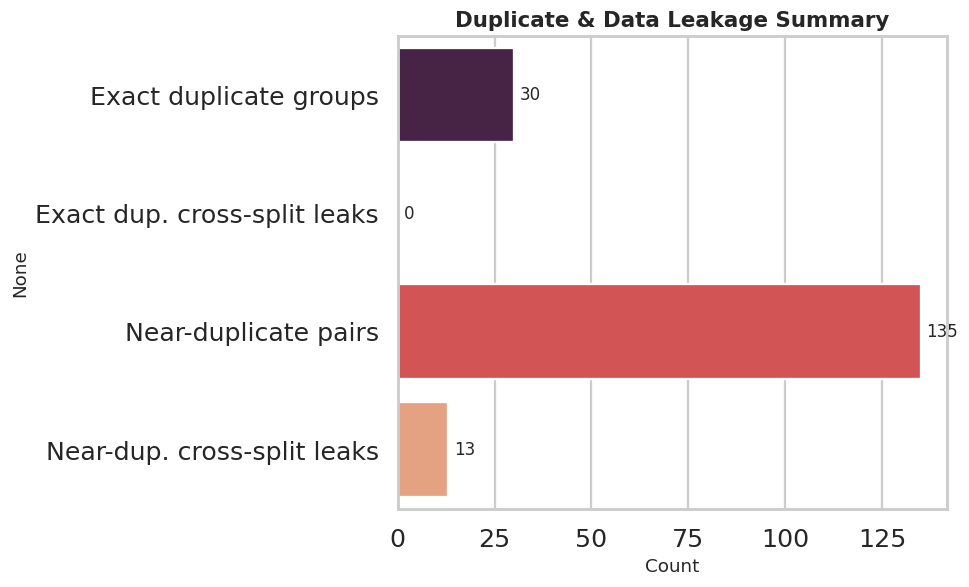

In [24]:
dup_summary = pd.Series({
    'Exact duplicate groups': n_exact_dup_groups,
    'Exact dup. cross-split leaks': n_exact_leaks,
    'Near-duplicate pairs': len(near_dup_df),
    'Near-dup. cross-split leaks': n_near_leaks,
})

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(x=dup_summary.values, y=dup_summary.index, hue=dup_summary.index,
            palette='rocket', legend=False, ax=ax)
for i, v in enumerate(dup_summary.values):
    ax.text(v + max(dup_summary.values, default=0) * 0.01 + 0.1, i, str(v), va='center', fontsize=11)
ax.set_title('Duplicate & Data Leakage Summary')
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/figures/07_duplicates_leakage.png')
plt.show()


## 8. Feature-Space Visualization (Deep Features)

We extract embeddings from a pretrained **MobileNetV2** (ImageNet weights, `pooling='avg'`),
then project them to 2D with PCA, t-SNE, and UMAP. If NORMAL/PNEUMONIA form visually separable
clusters even from a generic ImageNet backbone, the classification task is likely learnable;
heavy overlap suggests the two classes are harder to separate and/or that quality issues
(mislabeling, near-duplicates, inconsistent preprocessing) are blurring the boundary.

In [25]:
# Images per (split, class) combination used for feature extraction — tune for speed.
FEATURE_SAMPLE_PER_GROUP = 150

feature_sample_df = (
    manifest_df.groupby(['split', 'class'], group_keys=False)
    .apply(lambda g: g.sample(min(len(g), FEATURE_SAMPLE_PER_GROUP), random_state=SEED))
    .reset_index(drop=True)
)
print(f'Images selected for deep feature extraction: {len(feature_sample_df)}')

feature_extractor = MobileNetV2(weights='imagenet', include_top=False, pooling='avg',
                                 input_shape=(224, 224, 3))

def load_and_preprocess(filepath, target_size=(224, 224)):
    img = load_img(filepath, target_size=target_size)
    return preprocess_input(img_to_array(img))

BATCH_SIZE_FEAT = 32
features_list, valid_rows = [], []
batch_imgs, batch_rows = [], []

for _, row in tqdm(feature_sample_df.iterrows(), total=len(feature_sample_df),
                    desc='Extracting MobileNetV2 features'):
    try:
        batch_imgs.append(load_and_preprocess(row['filepath']))
        batch_rows.append(row)
    except Exception:
        continue
    if len(batch_imgs) == BATCH_SIZE_FEAT:
        features_list.append(feature_extractor.predict(np.stack(batch_imgs), verbose=0))
        valid_rows.extend(batch_rows)
        batch_imgs, batch_rows = [], []

if batch_imgs:
    features_list.append(feature_extractor.predict(np.stack(batch_imgs), verbose=0))
    valid_rows.extend(batch_rows)

features = np.vstack(features_list)
feature_meta_df = pd.DataFrame(valid_rows).reset_index(drop=True)
print(f'Feature matrix shape: {features.shape}')


Images selected for deep feature extraction: 616


I0000 00:00:1785426875.843458      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785426875.846547      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Extracting MobileNetV2 features:   0%|          | 0/616 [00:00<?, ?it/s]

2026-07-30 15:54:48.670716: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-30 15:54:48.808739: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1785426890.207170     141 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-07-30 15:55:07.518033: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-30 15:55:07.654150: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-o

Feature matrix shape: (616, 1280)


In [26]:
pca_components = min(50, features.shape[0] - 1, features.shape[1])
pca_50 = PCA(n_components=pca_components, random_state=SEED)
features_pca50 = pca_50.fit_transform(features)
print(f'Cumulative variance explained by {pca_50.n_components_} PCA components: '
      f'{pca_50.explained_variance_ratio_.sum():.3f}')

pca_2d = PCA(n_components=2, random_state=SEED)
features_pca2 = pca_2d.fit_transform(features)

tsne_2d = TSNE(n_components=2, perplexity=30, random_state=SEED, init='pca', learning_rate='auto')
features_tsne2 = tsne_2d.fit_transform(features_pca50)

umap_2d = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
features_umap2 = umap_2d.fit_transform(features_pca50)

feature_meta_df['pca_x'], feature_meta_df['pca_y'] = features_pca2[:, 0], features_pca2[:, 1]
feature_meta_df['tsne_x'], feature_meta_df['tsne_y'] = features_tsne2[:, 0], features_tsne2[:, 1]
feature_meta_df['umap_x'], feature_meta_df['umap_y'] = features_umap2[:, 0], features_umap2[:, 1]


Cumulative variance explained by 50 PCA components: 0.747


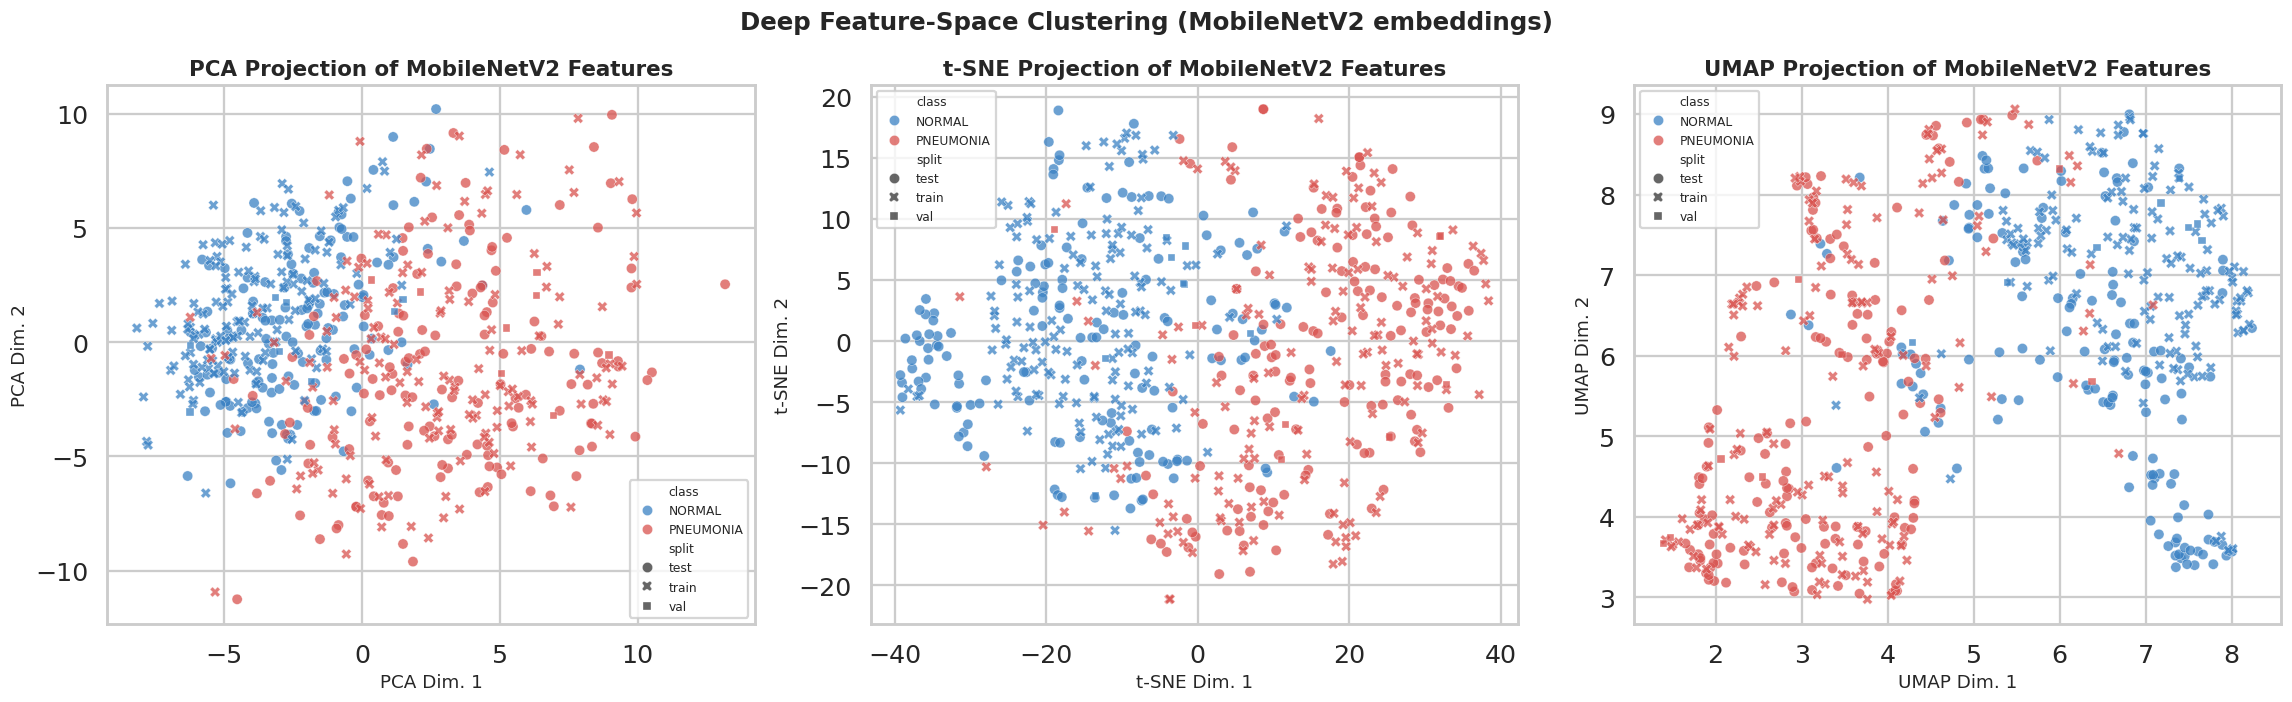

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))

for ax, (xcol, ycol, name) in zip(
    axes, [('pca_x', 'pca_y', 'PCA'), ('tsne_x', 'tsne_y', 't-SNE'), ('umap_x', 'umap_y', 'UMAP')]
):
    sns.scatterplot(
        data=feature_meta_df, x=xcol, y=ycol, hue='class', style='split',
        palette=PALETTE, alpha=0.75, s=45, ax=ax, edgecolor='white', linewidth=0.3
    )
    ax.set_title(f'{name} Projection of MobileNetV2 Features')
    ax.set_xlabel(f'{name} Dim. 1'); ax.set_ylabel(f'{name} Dim. 2')
    ax.legend(fontsize=8, loc='best')

plt.suptitle('Deep Feature-Space Clustering (MobileNetV2 embeddings)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/figures/08_feature_space.png')
plt.show()


## 9. Statistical Summary

In [28]:
statistical_summary = {
    'total_images': int(len(manifest_df)),
    'num_classes': int(manifest_df['class'].nunique()),
    'images_per_class': class_counts.to_dict(),
    'images_per_split': manifest_df['split'].value_counts().to_dict(),
    'imbalance_ratio': round(float(imbalance_ratio), 2),
    'avg_width': round(float(props_df['width'].mean()), 1),
    'avg_height': round(float(props_df['height'].mean()), 1),
    'avg_aspect_ratio': round(float(props_df['aspect_ratio'].mean()), 3),
    'mean_rgb': [round(float(pixel_df[c].mean()), 4) for c in ['mean_R', 'mean_G', 'mean_B']],
    'std_rgb': [round(float(pixel_df[c].mean()), 4) for c in ['std_R', 'std_G', 'std_B']],
    'pct_corrupted_in_sample': round(float(quality_df['corrupted'].mean() * 100), 2),
    'pct_blurry_in_sample': round(float(len(blurry_df) / len(quality_df) * 100), 2),
    'exact_duplicate_groups': n_exact_dup_groups,
    'exact_duplicate_cross_split_leaks': n_exact_leaks,
    'near_duplicate_pairs': int(len(near_dup_df)),
    'near_duplicate_cross_split_leaks': n_near_leaks,
}

summary_df = pd.DataFrame(list(statistical_summary.items()), columns=['Metric', 'Value'])
display(summary_df)

with open(f'{EDA_DIR}/statistical_summary.json', 'w') as f:
    json.dump(statistical_summary, f, indent=2, default=str)
summary_df.to_csv(f'{EDA_DIR}/statistical_summary.csv', index=False)

print(f'\nAll EDA artifacts (figures + summary tables) saved to: {os.path.abspath(EDA_DIR)}')


,Metric,Value
0,total_images,5856
1,num_classes,2
2,images_per_class,"{'NORMAL': 1583, 'PNEUMONIA': 4273}"
3,images_per_split,"{'train': 5216, 'test': 624, 'val': 16}"
4,imbalance_ratio,2.7
5,avg_width,1449.8
6,avg_height,1102.9
7,avg_aspect_ratio,1.387
8,mean_rgb,"[0.4798, 0.4798, 0.4798]"
9,std_rgb,"[0.229, 0.229, 0.229]"



All EDA artifacts (figures + summary tables) saved to: /kaggle/working/eda_outputs


## 10. Recommendations

In [29]:
print('=' * 70)
print('EDA-DRIVEN RECOMMENDATIONS')
print('=' * 70)

recommendations = []

if imbalance_ratio > 1.3:
    recommendations.append(
        f"- CLASS IMBALANCE ({imbalance_ratio:.2f}:1, {majority_class} majority): keep using "
        f"class_weight='balanced' (already applied later in this notebook) and/or oversample "
        f"{minority_class} via augmentation. Report Precision/Recall/F1 and ROC-AUC per class "
        f"rather than relying on accuracy alone, since accuracy is misleading under imbalance."
    )

if statistical_summary['pct_corrupted_in_sample'] > 0:
    recommendations.append(
        f"- CORRUPTED FILES: {statistical_summary['pct_corrupted_in_sample']:.2f}% of sampled "
        f"images failed integrity checks. Add a validation/filter pass before training "
        f"(ImageDataGenerator can crash or silently skip on these)."
    )

if statistical_summary['pct_blurry_in_sample'] > 5:
    recommendations.append(
        f"- LOW-SHARPNESS IMAGES: {statistical_summary['pct_blurry_in_sample']:.2f}% of sampled "
        f"images fall below the blur threshold. Manually review the flagged images — some low "
        f"scores are normal for chest X-rays with large soft-tissue regions, but very low scores "
        f"can indicate motion blur or scanning artifacts worth excluding."
    )

if n_exact_leaks > 0 or n_near_leaks > 0:
    recommendations.append(
        f"- DATA LEAKAGE: {n_exact_leaks} exact-duplicate group(s) and {n_near_leaks} near-"
        f"duplicate pair(s) span more than one split. This inflates validation/test accuracy. "
        f"Remove or reassign these images so no (near-)duplicate appears in both a training "
        f"split and an evaluation split, then re-run the experiments."
    )

if props_df['width'].std() > 50 or props_df['height'].std() > 50:
    recommendations.append(
        "- RESOLUTION VARIANCE: source image dimensions vary noticeably. A plain resize to "
        "224x224 (current IMG_SIZE) can distort chest anatomy; consider resize-with-padding "
        "('letterboxing') to preserve aspect ratio instead."
    )

recommendations.append(
    "- AUGMENTATION: the lighter policy already in this notebook (small rotation, horizontal "
    "flip, brightness jitter, no width/height shift or zoom) matches the framing and aspect-"
    "ratio patterns observed above, and avoids cropping out clinically relevant lung regions."
)

recommendations.append(
    "- MODEL PERFORMANCE IMPACT: the imbalance ratio, any cross-split leakage, and the corrupted/"
    "blurry image rate found above are the most likely explanations if validation/test metrics "
    "look unstable or inflated across experiments 1-5 — leakage in particular can make a model "
    "look better than it will perform on truly unseen data."
)

for r in recommendations:
    print(r, '\n')


EDA-DRIVEN RECOMMENDATIONS
- CLASS IMBALANCE (2.70:1, PNEUMONIA majority): keep using class_weight='balanced' (already applied later in this notebook) and/or oversample NORMAL via augmentation. Report Precision/Recall/F1 and ROC-AUC per class rather than relying on accuracy alone, since accuracy is misleading under imbalance. 

- LOW-SHARPNESS IMAGES: 30.50% of sampled images fall below the blur threshold. Manually review the flagged images — some low scores are normal for chest X-rays with large soft-tissue regions, but very low scores can indicate motion blur or scanning artifacts worth excluding. 

- DATA LEAKAGE: 0 exact-duplicate group(s) and 13 near-duplicate pair(s) span more than one split. This inflates validation/test accuracy. Remove or reassign these images so no (near-)duplicate appears in both a training split and an evaluation split, then re-run the experiments. 

- RESOLUTION VARIANCE: source image dimensions vary noticeably. A plain resize to 224x224 (current IMG_SIZE)